In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [53]:
df = pd.read_csv('/content/car data.csv')

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [54]:
print("Dataset Shape:", df.shape)

Dataset Shape: (301, 9)


In [55]:
print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [57]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [58]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [59]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


In [60]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [61]:
print("Fuel Types:")
print(df['Fuel_Type'].value_counts())

print("\nSelling Types:")
print(df['Selling_type'].value_counts())

print("\nTransmission:")
print(df['Transmission'].value_counts())

Fuel Types:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Selling Types:
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [62]:
current_year = 2026

df['Car_Age'] = current_year - df['Year']

df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [63]:
print(df['Selling_Price'].describe())

count    299.000000
mean       4.589632
std        4.984240
min        0.100000
25%        0.850000
50%        3.510000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64


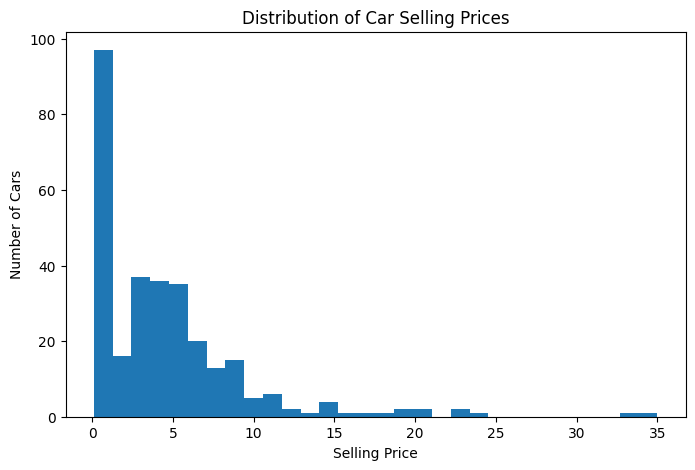

In [64]:
plt.figure(figsize=(8, 5))

plt.hist(df['Selling_Price'], bins=30)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

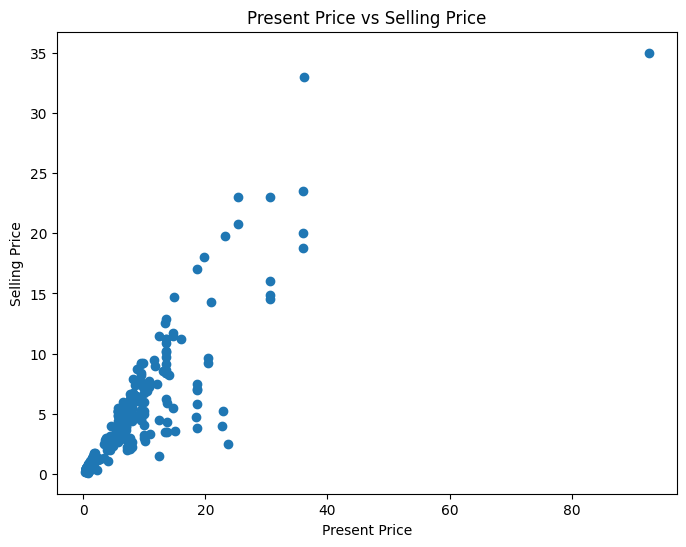

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Present_Price'],
    df['Selling_Price']
)

plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')

plt.show()

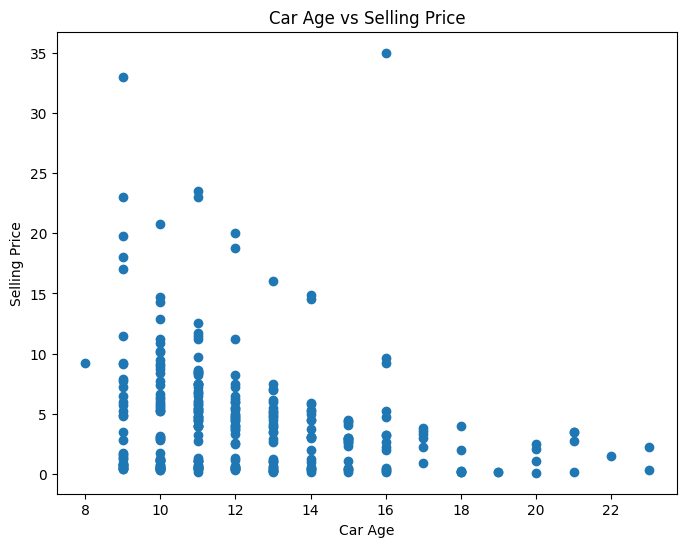

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Car_Age'],
    df['Selling_Price']
)

plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')

plt.show()

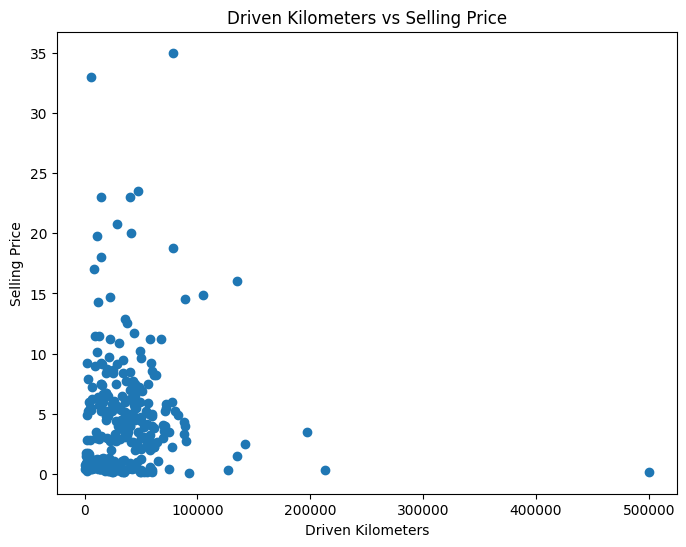

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Driven_kms'],
    df['Selling_Price']
)

plt.title('Driven Kilometers vs Selling Price')
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price')

plt.show()

In [68]:
fuel_price = df.groupby('Fuel_Type')['Selling_Price'].mean()

print(fuel_price)

Fuel_Type
CNG        3.100000
Diesel    10.102759
Petrol     3.264184
Name: Selling_Price, dtype: float64


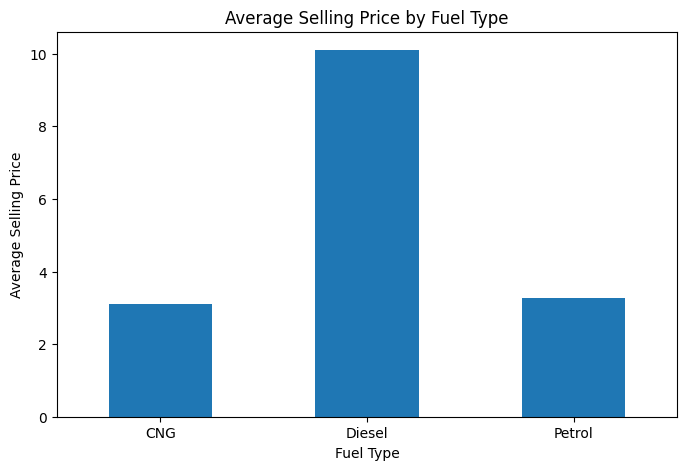

In [69]:
plt.figure(figsize=(8, 5))

fuel_price.plot(kind='bar')

plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=0)

plt.show()

In [70]:
transmission_price = df.groupby(
    'Transmission'
)['Selling_Price'].mean()

print(transmission_price)

Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


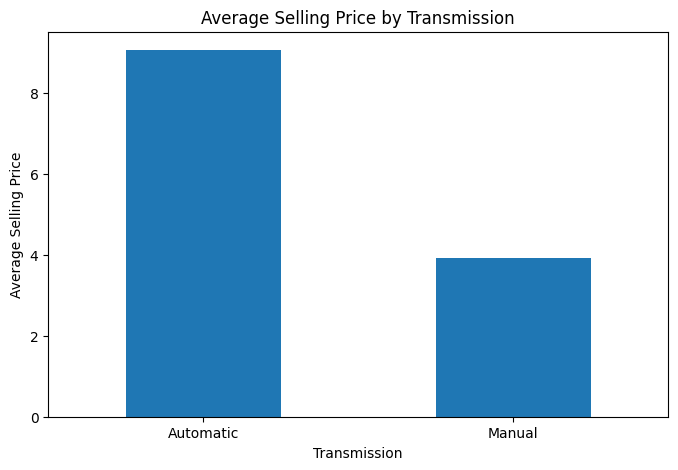

In [71]:
plt.figure(figsize=(8, 5))

transmission_price.plot(kind='bar')

plt.title('Average Selling Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=0)

plt.show()

In [72]:
numeric_columns = [
    'Year',
    'Selling_Price',
    'Present_Price',
    'Driven_kms',
    'Owner',
    'Car_Age'
]

correlation = df[numeric_columns].corr()

print(correlation)

                   Year  Selling_Price  Present_Price  Driven_kms     Owner  \
Year           1.000000       0.234369      -0.053167   -0.525714 -0.181639   
Selling_Price  0.234369       1.000000       0.876305    0.028566 -0.087880   
Present_Price -0.053167       0.876305       1.000000    0.205224  0.009948   
Driven_kms    -0.525714       0.028566       0.205224    1.000000  0.089367   
Owner         -0.181639      -0.087880       0.009948    0.089367  1.000000   
Car_Age       -1.000000      -0.234369       0.053167    0.525714  0.181639   

                Car_Age  
Year          -1.000000  
Selling_Price -0.234369  
Present_Price  0.053167  
Driven_kms     0.525714  
Owner          0.181639  
Car_Age        1.000000  


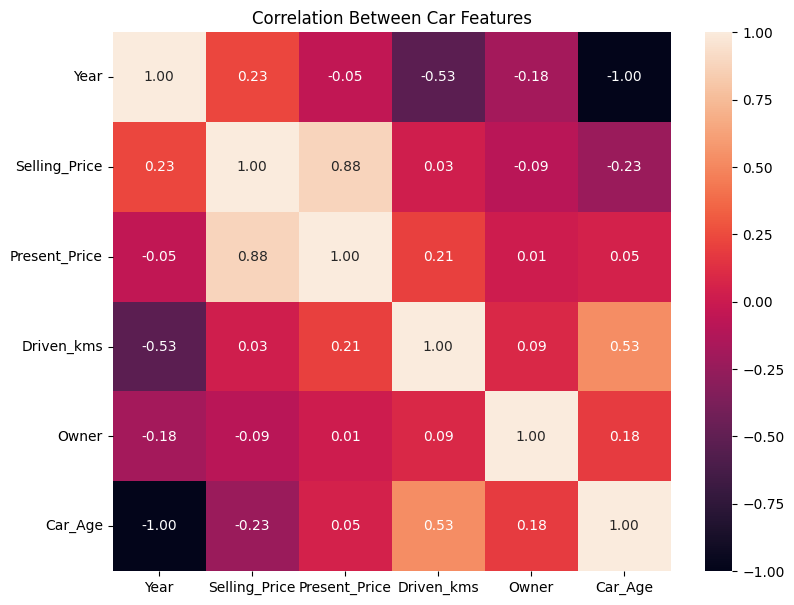

In [73]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Car Features')

plt.show()

In [74]:
X = df[
    [
        'Present_Price',
        'Driven_kms',
        'Fuel_Type',
        'Selling_type',
        'Transmission',
        'Owner',
        'Car_Age'
    ]
]

y = df['Selling_Price']

In [75]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Present_Price  Driven_kms Fuel_Type Selling_type Transmission  Owner  \
0           5.59       27000    Petrol       Dealer       Manual      0   
1           9.54       43000    Diesel       Dealer       Manual      0   
2           9.85        6900    Petrol       Dealer       Manual      0   
3           4.15        5200    Petrol       Dealer       Manual      0   
4           6.87       42450    Diesel       Dealer       Manual      0   

   Car_Age  
0       12  
1       13  
2        9  
3       15  
4       12  

Target:
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [76]:
categorical_features = [
    'Fuel_Type',
    'Selling_type',
    'Transmission'
]

numerical_features = [
    'Present_Price',
    'Driven_kms',
    'Owner',
    'Car_Age'
]

In [77]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 7)
Testing data: (60, 7)


In [79]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [80]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [81]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

In [82]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Selling_type',
                                                   'Transmission'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [83]:
y_pred = pipeline.predict(X_test)
print(y_pred[:10])

[ 9.46765  8.25525  0.4334   6.91275 18.25945  5.318    6.80305  1.19075
  7.83725  0.3138 ]


In [84]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.531740833333333


In [85]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 13.69464367737501


In [86]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 3.70062747076425


In [87]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.46864919313290443


In [88]:
print("Model Evaluation")
print("-------------------------")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 2))

Model Evaluation
-------------------------
MAE : 1.53
MSE : 13.69
RMSE: 3.7
R²  : 0.47


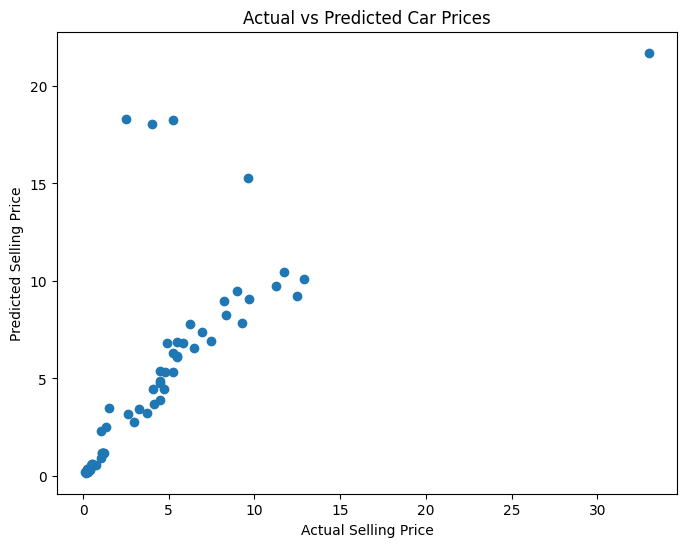

In [89]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

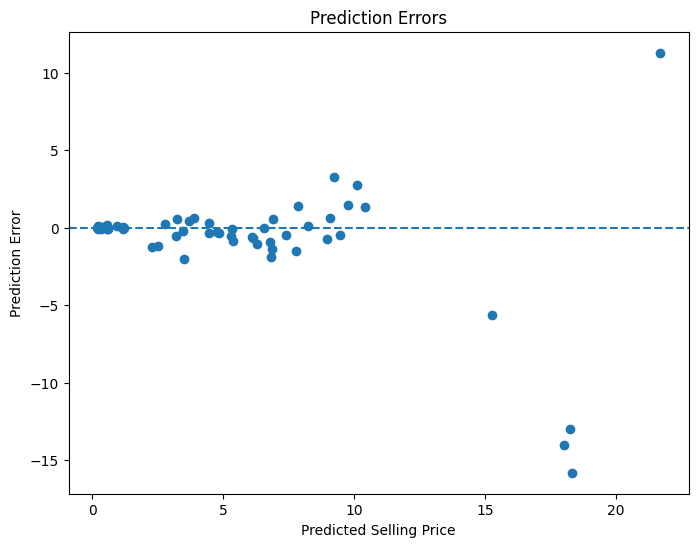

In [90]:
errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    errors
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Selling Price')
plt.ylabel('Prediction Error')
plt.title('Prediction Errors')

plt.show()

In [91]:
new_car = pd.DataFrame({
    'Present_Price': [8.5],
    'Driven_kms': [30000],
    'Fuel_Type': ['Petrol'],
    'Selling_type': ['Dealer'],
    'Transmission': ['Manual'],
    'Owner': [0],
    'Car_Age': [5]
})

predicted_price = pipeline.predict(new_car)

print(
    "Predicted Car Selling Price:",
    round(predicted_price[0], 2)
)

Predicted Car Selling Price: 6.89


In [92]:
new_car = pd.DataFrame({
    'Present_Price': [12.0],
    'Driven_kms': [20000],
    'Fuel_Type': ['Diesel'],
    'Selling_type': ['Dealer'],
    'Transmission': ['Automatic'],
    'Owner': [0],
    'Car_Age': [3]
})

predicted_price = pipeline.predict(new_car)

print(
    "Predicted Car Selling Price:",
    round(predicted_price[0], 2)
)

Predicted Car Selling Price: 10.02


In [93]:
feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = pipeline.named_steps[
    'model'
].feature_importances_

In [94]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                                 Feature  Importance
7               remainder__Present_Price    0.901962
10                    remainder__Car_Age    0.072847
8                  remainder__Driven_kms    0.013127
5    categorical__Transmission_Automatic    0.003979
6       categorical__Transmission_Manual    0.003650
4   categorical__Selling_type_Individual    0.001336
3       categorical__Selling_type_Dealer    0.001184
2          categorical__Fuel_Type_Petrol    0.001001
1          categorical__Fuel_Type_Diesel    0.000904
9                       remainder__Owner    0.000008
0             categorical__Fuel_Type_CNG    0.000003


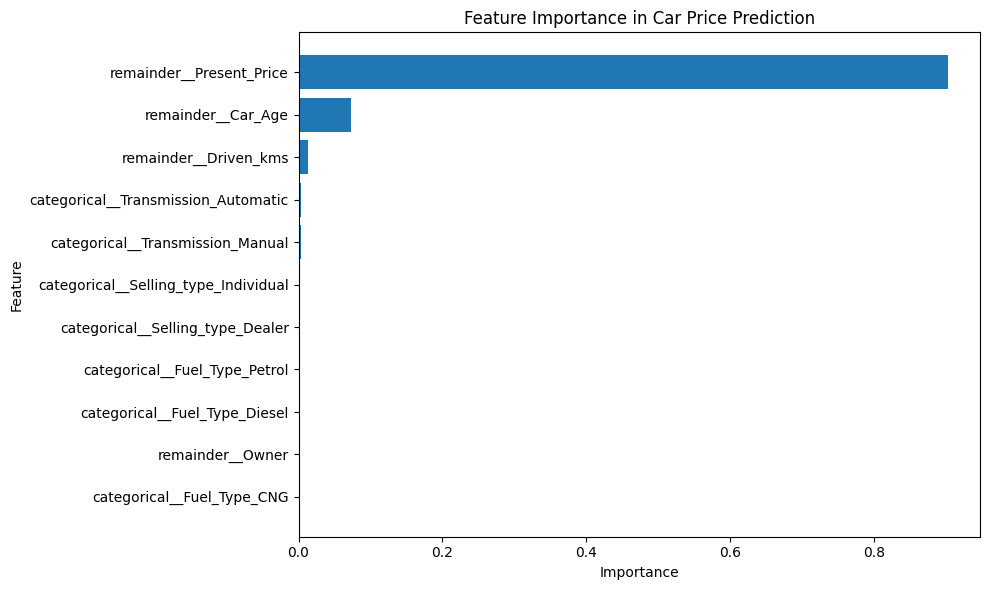

In [95]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Car Price Prediction')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Key Insights

1. The dataset initially contained 301 car records and 9 features.
   After removing 2 duplicate records, 299 records were used for
   analysis.

2. The average selling price of the cars in the dataset was 4.59,
   while the average present price was 7.54.

3. The average number of kilometres driven was approximately
   36,917 km. The dataset also contains considerable variation in
   vehicle usage, with driven kilometres ranging from 500 km to
   500,000 km.

4. Petrol cars were the most common fuel type, with 239 records,
   followed by Diesel with 58 records and CNG with 2 records.

5. Dealer sales were more common than individual sales, with
   193 dealer records compared with 106 individual records.

6. Manual transmission cars were much more common in the dataset,
   with 260 records, while automatic cars accounted for 39 records.

7. A Car_Age feature was created from the Year variable as part of
   feature engineering. This provides the model with information
   about the age of each vehicle.

8. Categorical variables such as Fuel_Type, Selling_type, and
   Transmission were converted using one-hot encoding before model
   training.

9. A Random Forest Regression model was trained using an 80/20
   train-test split. The model achieved an MAE of 1.53, an MSE of
   13.69, and an RMSE of 3.70.

10. The model achieved an R² score of 0.47, meaning that the model
    explains approximately 47% of the variation in selling prices
    on the test data. This indicates moderate predictive performance
    and also shows that additional features or model improvement
    could be useful.

11. The trained model successfully generated predictions for new
    car information. The example predictions in the notebook were
    6.89 and 10.02.

12. Overall, the analysis demonstrates that machine learning can be
    used to estimate used-car selling prices from vehicle
    characteristics such as present price, kilometres driven,
    vehicle age, fuel type, selling type, transmission, and number
    of previous owners.

## Conclusion

This project developed a machine learning model to predict used-car
selling prices using the provided car dataset.

The data was explored and cleaned by checking missing values and
removing duplicate records. Feature engineering was performed by
creating a Car_Age feature, while categorical variables were encoded
using one-hot encoding.

A Random Forest Regression model was trained using an 80/20
train-test split. The model achieved an MAE of 1.53, an MSE of 13.69,
an RMSE of 3.70, and an R² score of 0.47.

The model was also used to predict the selling prices of new example
cars, producing predictions of 6.89 and 10.02 for the two examples.

The project demonstrates a practical application of machine learning
for used-car price prediction and shows how vehicle characteristics
can be used to estimate resale prices.

In [96]:
import joblib

joblib.dump(
    pipeline,
    'car_price_prediction_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!
